# Goal:
We are going to generate 3 set of points, one affected by memory, one affected by an intrinsic potential/trend and one affected by both and see what we can do to that dataset


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import random as rd
import pandas as pd

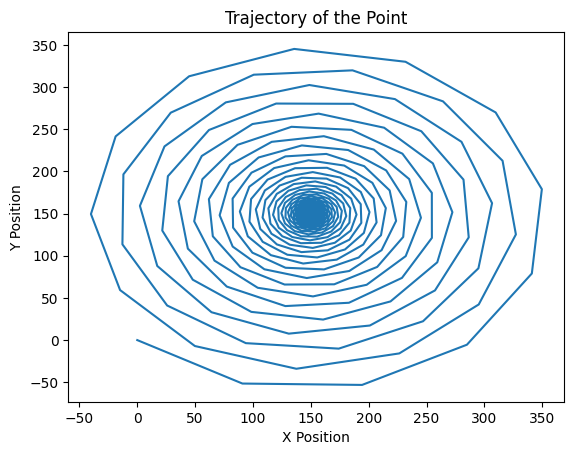

In [4]:
# coding the potential

def V(t, start_x=0, start_y=0, target_x=0, target_y=0):
    R = np.hypot(target_x - start_x, target_y - start_y)
    theta_0 = np.arctan2(start_y - target_y, start_x - target_x)

    r = R * np.exp(-0.1 * t)  
    x = target_x + r * np.cos(5 * t + theta_0)
    y = target_y + r * np.sin(5 * t + theta_0)
    return x, y

t = np.linspace(0, 1000, 10000)
x , y = V(t, 0, 0, target_x=150, target_y=150)

plt.plot(x, y)
plt.title('Trajectory of the Point')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.show()

Step 10: Current position: [  29.8449696  -106.33844378]
Step 20: Current position: [ 25.79101206 -90.06071969]
Step 30: Current position: [ 27.32415649 -90.56276291]
Step 40: Current position: [ 27.7396315  -91.10249951]
Step 50: Current position: [ 27.74857696 -91.15836767]
Step 60: Current position: [ 27.73314154 -91.14468335]
Step 70: Current position: [ 27.73007407 -91.13990228]
Step 80: Current position: [ 27.73016624 -91.13961566]
Step 90: Current position: [ 27.73030734 -91.13975983]
Step 100: Current position: [ 27.73032828 -91.13979672]
Step 110: Current position: [ 27.7303262 -91.1397973]
Step 120: Current position: [ 27.73032498 -91.1397959 ]
Step 130: Current position: [ 27.73032485 -91.13979563]
Step 140: Current position: [ 27.73032488 -91.13979564]
Step 150: Current position: [ 27.73032489 -91.13979565]
Step 160: Current position: [ 27.73032489 -91.13979566]
Step 170: Current position: [ 27.73032489 -91.13979566]
Step 180: Current position: [ 27.73032489 -91.13979566]
S

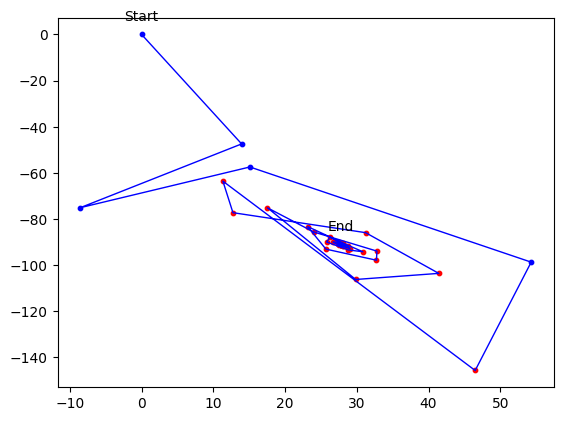

Total steps taken: 10001


In [5]:
# coding short-term memory

MEMORY_STATE = []
x_history = []
y_history = []
def M(start_x, start_y, memory_state, memory_weights, memory_extent, noise_level, seed, max_points, steps = 0):
    rd.seed(seed)
    x = [start_x, start_y]
    while True:
        steps += 1
        if len(memory_state) < memory_extent:
            x_history.append(x[0])
            y_history.append(x[1])
            # if not, just take a random step towards the target
            dev = np.array([rd.uniform(-noise_level, noise_level), rd.uniform(-noise_level, noise_level)])
            x = x + dev
            memory_state.append(x.copy())
        else:
            x_history.append(x[0])
            y_history.append(x[1])
            weighted_average = np.average(memory_state, axis=0, weights=memory_weights)
            # take a step towards the weighted average
            dev = weighted_average - x
            x = x + dev
            memory_state.append(x.copy())
            memory_state.pop(0)
        if steps % 10 == 0:
            print(f"Step {steps}: Current position: {x}")
        if steps > max_points:  # safety break to prevent infinite loops
            print("Reached maximum number of steps.")
            break
    return x_history, y_history, steps, memory_extent

x_history, y_history, steps, memory_extent = M(0, 0, MEMORY_STATE, [0.5, 0.3, 0.2, 0.05, 0.05], 5, 50, 42, 10000)

plt.plot(x_history, y_history, color='blue', linewidth=1)
plt.scatter(x_history[:memory_extent], y_history[:memory_extent], color='blue', s=10)
plt.scatter(x_history[memory_extent:], y_history[memory_extent:], color='red', s=10)
plt.annotate('Start', (x_history[0], y_history[0]), textcoords="offset points", xytext=(0, 10), ha='center')
plt.annotate('End', (x_history[-1], y_history[-1]), textcoords="offset points", xytext=(0, 10), ha='center')
plt.show()
print(f"Total steps taken: {steps}")

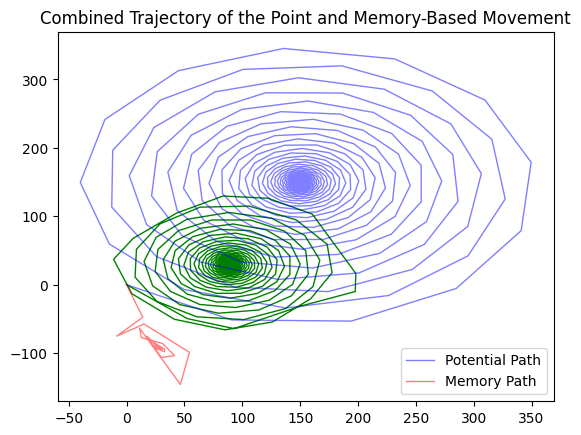

In [6]:
# combining the path of the point and the memory-based movement by averaging the two paths
x_avg = np.zeros(min(len(x), len(x_history)))
y_avg = np.zeros(min(len(y), len(y_history)))
for step in range(min(len(x), len(x_history))):
    x_avg[step] = (x[step] + x_history[step]) / 2
    y_avg[step] = (y[step] + y_history[step]) / 2
plt.plot(x_avg, y_avg, color='green', linewidth=1)
plt.plot(x, y, color='blue', linewidth=1, alpha=0.5, label='Potential Path')
plt.plot(x_history, y_history, color='red', linewidth=1, alpha=0.5, label='Memory Path')
plt.title('Combined Trajectory of the Point and Memory-Based Movement')
plt.legend()
plt.show()

The last system is trash as the walk is not random but becomes deterministic. We are going to generate a new system for the short-term memory. The way it functions is as follows:

1) Generate ``memory_extent`` number of random points in a 2D space. These points will serve as the "memory" of the system.
2) For each new point from now on, calculate the weighted average position of the last ``memory_extent`` points. The weights are pre-determined for now. Next, center a 2D Gaussian circle around the weighted average position. The new point is then sampled from this Gaussian distribution. This way, the new point is influenced by the recent history of points, creating a short-term memory effect.

Step 10: Current position: [ 2.26712522 -6.58709867]
Step 20: Current position: [ -1.19280284 -15.90723992]
Step 30: Current position: [ -1.05413217 -22.41924532]
Step 40: Current position: [ -1.14655275 -18.97901865]
Step 50: Current position: [ -6.06082831 -13.25888388]
Step 60: Current position: [ -6.64631788 -14.44094365]
Step 70: Current position: [ -3.75540815 -14.81754723]
Step 80: Current position: [ -5.35984245 -11.09459152]
Step 90: Current position: [-13.66360486 -10.6054456 ]
Step 100: Current position: [-15.09982378  -9.50323779]
Step 110: Current position: [-7.62576757 13.47399624]
Step 120: Current position: [-8.99255252  5.00381891]
Step 130: Current position: [-1.74919905  5.45573063]
Step 140: Current position: [-13.1693746   5.9708394]
Step 150: Current position: [-6.96538418 -5.78314635]
Step 160: Current position: [-1.00850485 -5.60242197]
Step 170: Current position: [3.54676951 2.59470258]
Step 180: Current position: [-1.71276921 -4.94734317]
Step 190: Current pos

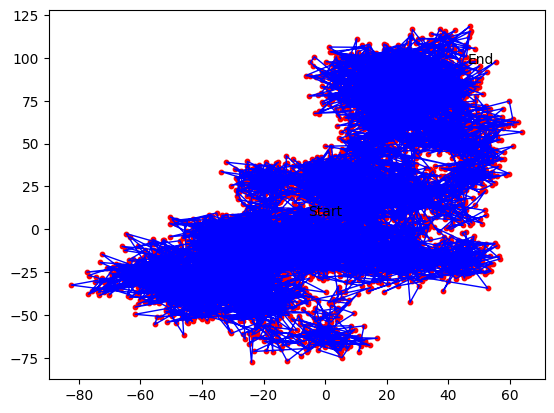

Total steps taken: 10001


In [7]:
# coding short-term random gaussian sampling memory
MEMORY_STATE = []
x_history = []
y_history = []
def M_gaussian(start_x, start_y, memory_state, memory_weights, memory_extent, noise_level, seed, max_points, steps = 0):
    rd.seed(seed)
    np.random.seed(seed)
    x = [start_x, start_y]
    while True:
        steps += 1
        if len(memory_state) < memory_extent:
            x_history.append(x[0])
            y_history.append(x[1])
            # if not, just take a random step towards the target
            dev = np.array([rd.uniform(-noise_level, noise_level), rd.uniform(-noise_level, noise_level)])
            x = x + dev
            memory_state.append(x.copy()) # same code for under memory_extent points
        else:
            x_history.append(x[0])
            y_history.append(x[1])
            # calculate the weighted average of the last memory_extent points
            weighted_average = np.average(memory_state, axis=0, weights=memory_weights)
            # sample a new point from a 2D Gaussian distribution centered at the weighted average
            new_point = np.random.normal(loc=weighted_average, scale=noise_level, size=2) # noise_level here acts as how much spread the Gaussian is and size is 2 for 2D
            x = new_point
            memory_state.append(x.copy())
            memory_state.pop(0)
        if steps % 10 == 0:
            print(f"Step {steps}: Current position: {x}")
        if steps > max_points:  # safety break to prevent infinite loops
            print("Reached maximum number of steps.")
            break
    return x_history, y_history, steps, memory_extent


x_history, y_history, steps, memory_extent = M_gaussian(0, 0, MEMORY_STATE, [0.5, 0.3, 0.2, 0.05, 0.05], 5, 5, 42, 10000)

plt.plot(x_history, y_history, color='blue', linewidth=1)
plt.scatter(x_history[:memory_extent], y_history[:memory_extent], color='blue', s=10)
plt.scatter(x_history[memory_extent:], y_history[memory_extent:], color='red', s=10)
plt.annotate('Start', (x_history[0], y_history[0]), textcoords="offset points", xytext=(0, 10), ha='center')
plt.annotate('End', (x_history[-1], y_history[-1]), textcoords="offset points", xytext=(0, 10), ha='center')
plt.show()
print(f"Total steps taken: {steps}")   

Length of x: 10000, Length of x_history: 10001


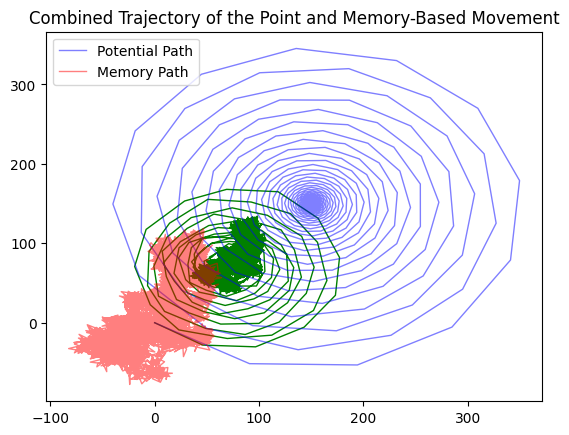

In [8]:
# let's plot the new memory and the potential together
x_avg = np.zeros(min(len(x), len(x_history)))
y_avg = np.zeros(min(len(y), len(y_history)))
print(f"Length of x: {len(x)}, Length of x_history: {len(x_history)}")
for step in range(min(len(x), len(x_history))):
    x_avg[step] = (x[step] + x_history[step]) / 2
    y_avg[step] = (y[step] + y_history[step]) / 2
plt.plot(x_avg, y_avg, color='green', linewidth=1)
plt.plot(x, y, color='blue', linewidth=1, alpha=0.5, label='Potential Path')
plt.plot(x_history, y_history, color='red', linewidth=1, alpha=0.5, label='Memory Path')
plt.title('Combined Trajectory of the Point and Memory-Based Movement')
plt.legend()
plt.show()

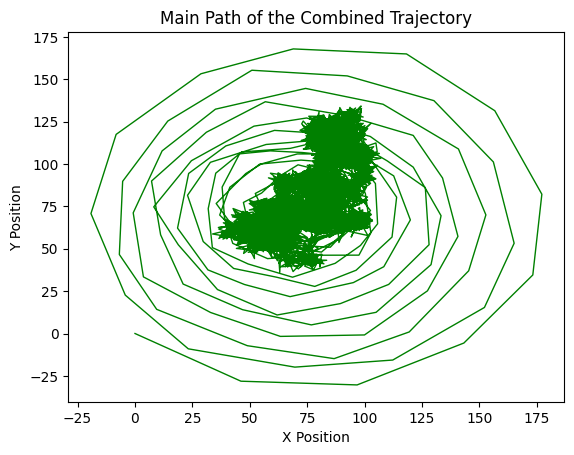

In [9]:
# only the main path

plt.plot(x_avg, y_avg, color='green', linewidth=1)
plt.title('Main Path of the Combined Trajectory')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.show()

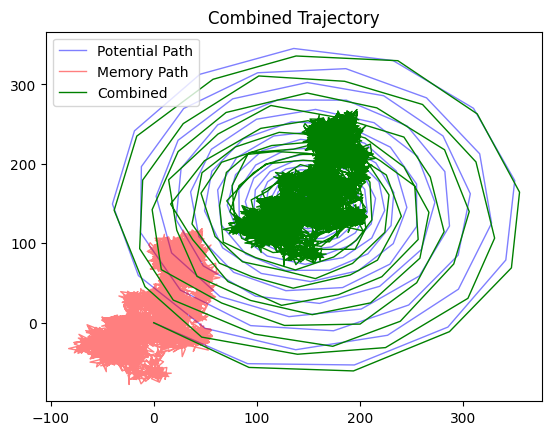

In [10]:
# let's try simple addition
limit = min(len(x), len(x_history))
x_combined = np.array(x[:limit]) + np.array(x_history[:limit])
y_combined = np.array(y[:limit]) + np.array(y_history[:limit])
plt.plot(x, y, color='blue', linewidth=1, alpha=0.5, label='Potential Path')
plt.plot(x_history, y_history, color='red', linewidth=1, alpha=0.5, label='Memory Path')
plt.plot(x_combined, y_combined, color='green', linewidth=1, label='Combined')
plt.title('Combined Trajectory')
plt.legend()
plt.show()

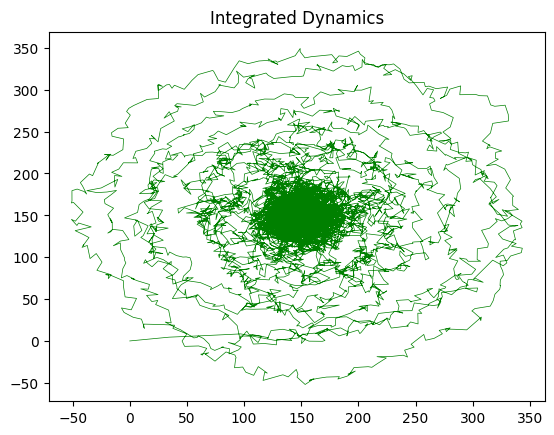

In [11]:
# doing something gemini pulled and modifying it

def combined_dynamics(start_x, start_y, target_x, target_y, memory_extent, memory_weights, noise_level, max_steps, spiral_factor, memory_factor):
    # Initialize the starting position and memory state
    x = np.array([start_x, start_y], dtype=float)
    memory_state = []
    x_hist, y_hist = [], []
    
    # Pre-calculate spiral parameters, that is the initial distance and angle to the target
    R = np.hypot(target_x - start_x, target_y - start_y)
    theta_0 = np.arctan2(start_y - target_y, target_x - start_x)
    
    for step in range(max_steps): # loop over the number of steps
        x_hist.append(x[0]) 
        y_hist.append(x[1]) # add point to history
        
        # 1. Potential Pull
        t = (step / max_steps) * 50 # scale t to a reasonable range for the spiral, if we don't scale it, the spiral will be too tight and the point will not move much
        r = R * np.exp(-0.1 * t) # calculate the radius of the spiral at t
        ideal_pos = np.array([
            target_x + r * np.cos(5 * t + theta_0),
            target_y + r * np.sin(5 * t + theta_0)
        ]) # calculate the ideal position on the spiral at t
        potential_pull = (ideal_pos - x) * spiral_factor # calculate the pull towards the ideal position of the current point, by how much scale it moves towards the ideal position, spiral_factor is a scaling factor that can be adjusted to make the pull stronger or weaker
        
        # 2. Memory Pull
        if len(memory_state) < memory_extent:
            memory_pull = np.array([0.0, 0.0])
            noise = np.random.normal(scale=noise_level, size=2)
        else:
            weighted_avg = np.average(memory_state, axis=0, weights=memory_weights) # calculate the weighted average of the last memory_extent points
            memory_pull = (weighted_avg - x) * memory_factor # calculate the pull towards the weighted average of the last memory_extent points, by how much scale it moves towards the weighted average, memory_factor is a scaling factor that can be adjusted to make the pull stronger or weaker
            noise = np.random.normal(scale=noise_level, size=2) # define the noise to be added to the point, the noise is sampled from a normal distribution with mean 0 and standard deviation noise_level, this makes the point move randomly around the weighted average of the last memory_extent points, creating a short-term memory effect, since memory isn't perfect, the point will not always move directly towards the weighted average, but will be influenced by it, creating a more natural and less deterministic movement
            memory_state.pop(0)

        # apply the combined effect of potential pull, memory pull, and noise to the current position
        x = x + potential_pull + memory_pull + noise
        memory_state.append(x.copy())
        
    return x_hist, y_hist

# Run it
x_hist, y_hist = combined_dynamics(
    start_x=0, start_y=0, 
    target_x=150, target_y=150, 
    memory_extent=5, 
    memory_weights=[0.5, 0.3, 0.2, 0.05, 0.05], 
    noise_level=5, 
    max_steps=10000, spiral_factor=0.1, memory_factor=0.1
)

plt.plot(x_hist, y_hist, color='green', linewidth=0.5)
plt.title('Integrated Dynamics')
plt.show()

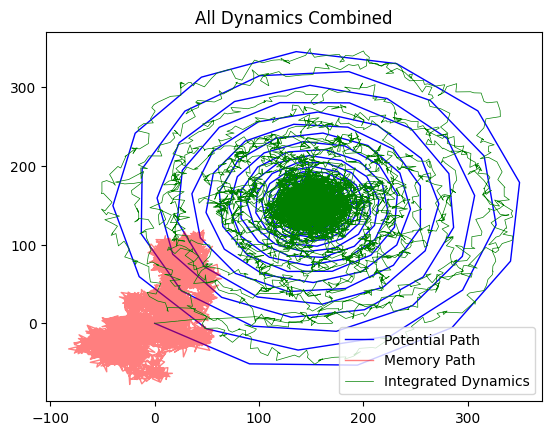

In [12]:
# everything plotted together
plt.plot(x, y, color='blue', linewidth=1, alpha=1, label='Potential Path')
plt.plot(x_history, y_history, color='red', linewidth=1, alpha=0.5, label='Memory Path')
plt.plot(x_hist, y_hist, color='green', linewidth=0.5, label='Integrated Dynamics')
plt.title('All Dynamics Combined')
plt.legend()
plt.show()

This shall serve as the dataset for our short-term memory system. We are now going to try to train a model to predict the potential function given the memory function and the integrated path.

In [13]:
# saving the datasets

potential_df = pd.DataFrame({'x': x, 'y': y})
memory_df = pd.DataFrame({'x': x_history, 'y': y_history})
main_path_df = pd.DataFrame({'x': x_hist, 'y': y_hist})

potential_df.to_csv('data/potential_path.csv', index=False)
memory_df.to_csv('data/memory_path.csv', index=False)
main_path_df.to_csv('data/main_path.csv', index=False)